# <font color='magenta'>Metody rozwiązywania równań różniczkowych</font>
---
## Przykład - rozwiązanie równania różniczkowego za pomocą metody RK4 oraz funkcji odeint

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [ ]:
# Parametry obwodu
R = 1 # Rezystancja [Ω]
L = 0.01  # Indukcyjność [H]
f = 50   # Częstotliwość [Hz]
omega = 2 * np.pi * f  # Częstotliwość kątowa [rad/s]
V_max = 100  # Amplituda napięcia [V]

In [ ]:
# Funkcja napięcia źródłowego
def V(t):
    return V_max * np.sin(omega * t)

In [ ]:
# Równanie różniczkowe obwodu RL: L*di/dt + R*i = V(t)
def model(i, t):
    dI_dt = (V(t) - R * i) / L
    return dI_dt

In [ ]:
# Czas symulacji
t = np.linspace(0, 3/f, 1000)  # 3 okresy

# Warunki początkowe
i0 = 0  # Początkowy prąd

In [ ]:
# Rozwiązanie równania różniczkowego
I = odeint(model, i0, t)

# Obliczenie przesunięcia fazowego
phi = np.arctan(omega * L / R)  # Teoretyczne przesunięcie fazowe [rad]
phi_deg = np.degrees(phi)  # Przesunięcie w stopniach

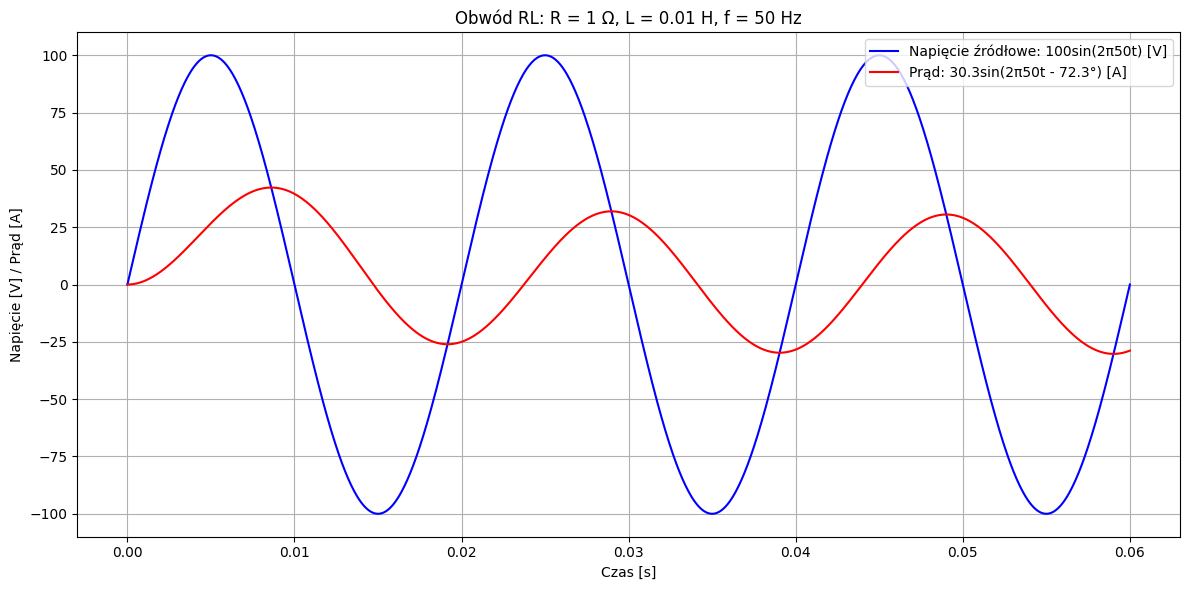

In [ ]:
# Wykres
plt.figure(figsize=(12, 6))

plt.plot(t, V(t), 'b-', label=f'Napięcie źródłowe: {V_max}sin(2π{f}t) [V]')
plt.plot(t, I, 'r-', label=f'Prąd: {V_max/np.sqrt(R**2 + (omega*L)**2):.1f}sin(2π{f}t - {phi_deg:.1f}°) [A]')

plt.title(f'Obwód RL: R = {R} Ω, L = {L} H, f = {f} Hz')
plt.xlabel('Czas [s]')
plt.ylabel('Napięcie [V] / Prąd [A]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Implementacje metod Rungego-Kutty

In [ ]:
# RK4
def rk4(f, y0, t):
    n = len(t)
    y = np.zeros(n)
    y[0] = y0
    h = t[1] - t[0]  # stały krok czasowy

    for i in range(n - 1):
        k1 = f(y[i], t[i])
        k2 = f(y[i] + 0.5 * h * k1, t[i] + 0.5 * h)
        k3 = f(y[i] + 0.5 * h * k2, t[i] + 0.5 * h)
        k4 = f(y[i] + h * k3, t[i] + h)

        y[i + 1] = y[i] + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    return y

Parametry

In [ ]:
y0 = 1.0    # Warunek początkowy
t0 = 0.0    # Czas początkowy
tf = 0.003   # Czas końcowy
h = 0.000001     # Krok czasowy

In [ ]:
t = np.linspace(0, 3/f, 1000)
print(t[-1])
# Warunek początkowy
i0 = 0  # Początkowy prąd

0.06


In [ ]:
# Rozwiązanie metodą RK4
I_rk4 = rk4(model, i0, t)

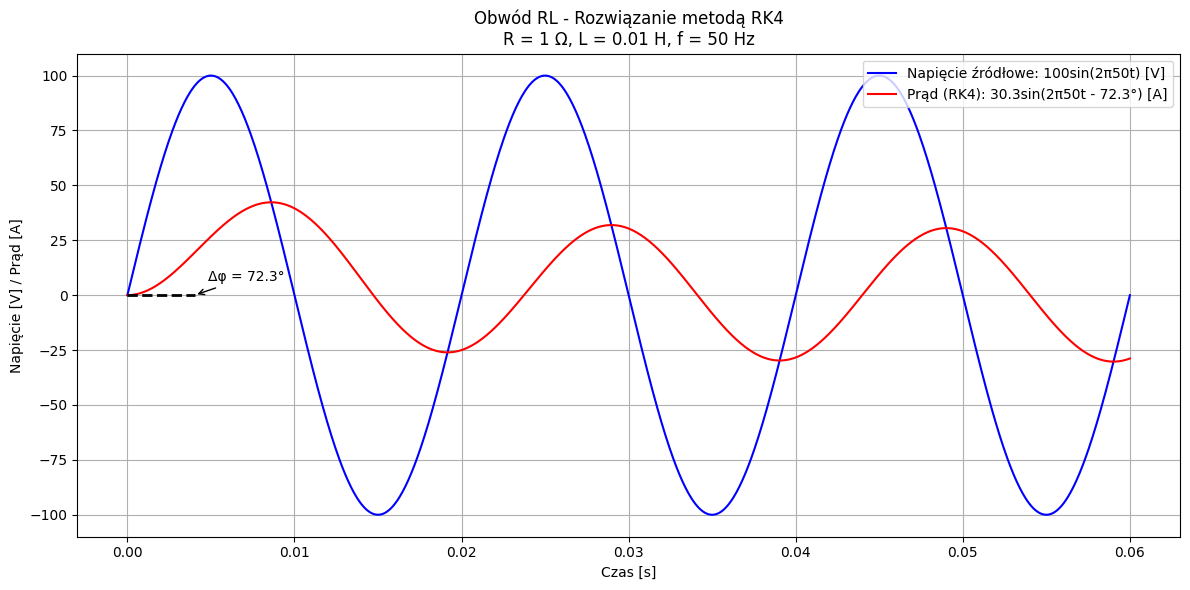

In [ ]:
# Obliczenie przesunięcia fazowego
phi = np.arctan(omega * L / R)  # Teoretyczne przesunięcie fazowe [rad]
phi_deg = np.degrees(phi)  # Przesunięcie w stopniach

# Wykres
plt.figure(figsize=(12, 6))

plt.plot(t, V(t), 'b-', label=f'Napięcie źródłowe: {V_max}sin(2π{f}t) [V]')
plt.plot(t, I_rk4, 'r-', label=f'Prąd (RK4): {V_max/np.sqrt(R**2 + (omega*L)**2):.1f}sin(2π{f}t - {phi_deg:.1f}°) [A]')


# Zaznaczenie przesunięcia fazowego
t_phase = np.array([0, phi/omega])
plt.plot(t_phase, [0, 0], 'k--', linewidth=2)
plt.annotate(f'Δφ = {phi_deg:.1f}°',
             xy=(phi/omega, 0), xytext=(10, 10),
             textcoords='offset points',
             arrowprops=dict(arrowstyle="->"))

plt.title(f'Obwód RL - Rozwiązanie metodą RK4\nR = {R} Ω, L = {L} H, f = {f} Hz')
plt.xlabel('Czas [s]')
plt.ylabel('Napięcie [V] / Prąd [A]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()